
## Problem 2 (10 points): Theoretical Motivation for WLS

**Goal of this problem**: Students will learn about why we often use the *weighted* least-squares solution rather than the (ordinary) least-squares solution of the navigation equations.  
What are the assumptions of this solution? Are these assumptions valid?

In Lecture 4, we derived the (ordinary) least-squares (OLS) solution to the linearized navigation equations as:

$$
\delta \mathbf{y} =
\begin{bmatrix}
\delta \mathbf{x} \\
\delta b
\end{bmatrix} =
\left( G^\top G \right)^{-1} G^\top \delta \rho,
$$

where $\delta \mathbf{y} \in \mathbb{R}^{4}$ is the correction to our state consisting of a position correction $\delta \mathbf{x} \in \mathbb{R}^3$ and a clock bias correction $\delta b \in \mathbb{R}$, $\delta \rho \in \mathbb{R}^{N}$ is the vector of pseudorange residuals for $N$ visible satellites, and $G \in \mathbb{R}^{N \times 4}$ is the geometry matrix.  

Ideally, we want the pseudorange residuals to be near zero (i.e., $\delta \rho \approx \mathbf{0}$), but we cannot achieve zero residuals in practice due to measurement errors. For example, the residuals can be $10-100~\text{m}$ in harsh urban environments!  

In what sense is the (ordinary) least-squares solution (OLS) the *best* or *optimal* solution?  
Building on the shoulders of giants, the work of Gauss (1777–1855) and Markov (1856–1922) proved that the OLS estimator is the *best linear unbiased estimator (BLUE)* under certain assumptions on the error.  

First, what does BLUE mean?

- *Best* refers to the estimator with the minimum variance among all possible estimators with the restrictions and assumptions below.  
- *Linear* refers to restricting to a linear model (i.e., $\delta \rho = G \, \delta \mathbf{y}$ is linear).  
- *Unbiased* [1] refers to restricting the estimator to be centered around the true value if you repeat the estimation many times with new data.  
- *Estimator* refers to the procedure to *estimate* an unknown quantity from data.  

The assumptions on the error are quite important.  
Specifically, this is the error $\boldsymbol{\epsilon}$ in the linear model $\delta \rho = G \, \delta \mathbf{y} + \boldsymbol{\epsilon}$.  
The three assumptions [2] are below.
The figure below illustrates these assumptions more graphically.

1. **Errors are uncorrelated**. The error $\epsilon^{(1)}$ from the pseudorange measurement of satellite 1 is not correlated with the error $\epsilon^{(2)}$ from the pseudorange measurement of satellite 2, and so on with the other satellites.  
2. **Errors have equal variance** (AKA “spherical errors”). The errors $\epsilon^{(1)}$ from the pseudorange measurement in satellite 1 have a distribution with the same variances as the errors $\epsilon^{(2)}$ in satellite 2, and so on with the other satellites.  
3. **Errors have an expected value (i.e., mean) of zero**. If we get many measurements from satellite 1, then the mean of the pseudorange residuals will be zero.    


In practice, the second assumption is almost never true. Fortunately, Aitken (1895–1967) found a way to generalize least-squares estimation to remove the first and second assumptions. Aitken’s approach is called *generalized least-squares (GLS)* [3], but it requires good knowledge of the error distribution, which is quite difficult to achieve in practice. Moreover, approaches to estimate the correlation and variance between errors tend to be quite computationally heavy.  

So, instead, we only drop the second assumption and try to account for the differences in variance between measurements, but we do not account for the correlation between errors. This approach is called **weighted least-squares (WLS)**. It turns out to be pretty good, which is why people still use it. We will see more about WLS in Lecture 6.  

To provide intuition, we want to put a *larger* weight on satellites where the variance is *small* since these measurements provide a more precise understanding of the user location. Likewise, we want to put a *smaller* weight on satellites where the variance is *large* (Figure above).  

To incorporate relative weighting of the pseudorange measurements, we will redefine our problem statement for the “best” $\delta \mathbf{y}$ solution to be:

$$
\arg \min_{\delta \mathbf{y}} \ \lVert \delta \rho - G \, \delta \mathbf{y} \rVert_W^2,
$$

where $W = \text{diag}\left( w_1, w_2, \cdots, w_N \right)$ is a diagonal weighting matrix with positive weights $w_i$, and $\lVert \cdot \rVert_W$ is the Mahalanobis norm, defined as:

$$
\lVert \mathbf{z} \rVert_W^2 = \mathbf{z}^\top W \mathbf{z},
$$

where $\mathbf{z}\in \mathbb{R}^{N}$.  

To provide intuition, the normal Euclidean distance (i.e., the Euclidean norm) arises if $W = I$, where $I$ is the identity matrix. The contours of the Euclidean norm are circles whereas the contours of the Mahalanobis norm are ellipses.

[1]: The restriction on “unbiased” estimation is critical. There are biased estimators with lower variance. For example, “regularization” is a common bias that is introduced to lower variance, especially in a least-squares context. For more, I recommend AA 222 (Optimization) and CS/STATS 229 (Machine Learning).


[2]: Often, people incorrectly list an assumption or requirement that the errors *must* follow a multivariate Gaussian (i.e., a normal distribution). However, we do not *require* that the errors are distributed as a multivariate Gaussian. But, it turns out that we can make even stronger claims about least-squares estimation if the errors are Gaussian, as we assumed in Lecture 4. In many cases, GPS/GNSS errors can be well-modelled as Gaussians. For more, I recommend AA 273 (State Estimation) and CS/STATS 229 (Machine Learning).

[3]: Check out Chapter 6 of the GPS textbook and [Wikipedia: Generalized least squares](https://en.wikipedia.org/wiki/Generalized_least_squares).

In [ ]:
import numpy as np
import pandas as pd
from google.colab import drive
import os
from dataclasses import dataclass

if not os.path.ismount("/content/drive"):
    print("Mounting Google Drive...")
    drive.mount("/content/drive")
else:
    print("Google Drive already mounted")
gdrive = True
notebooks_dir = os.path.join("/content/drive/MyDrive/AA 272 - GPS Class/HW2")

Mounting Google Drive...
Mounted at /content/drive


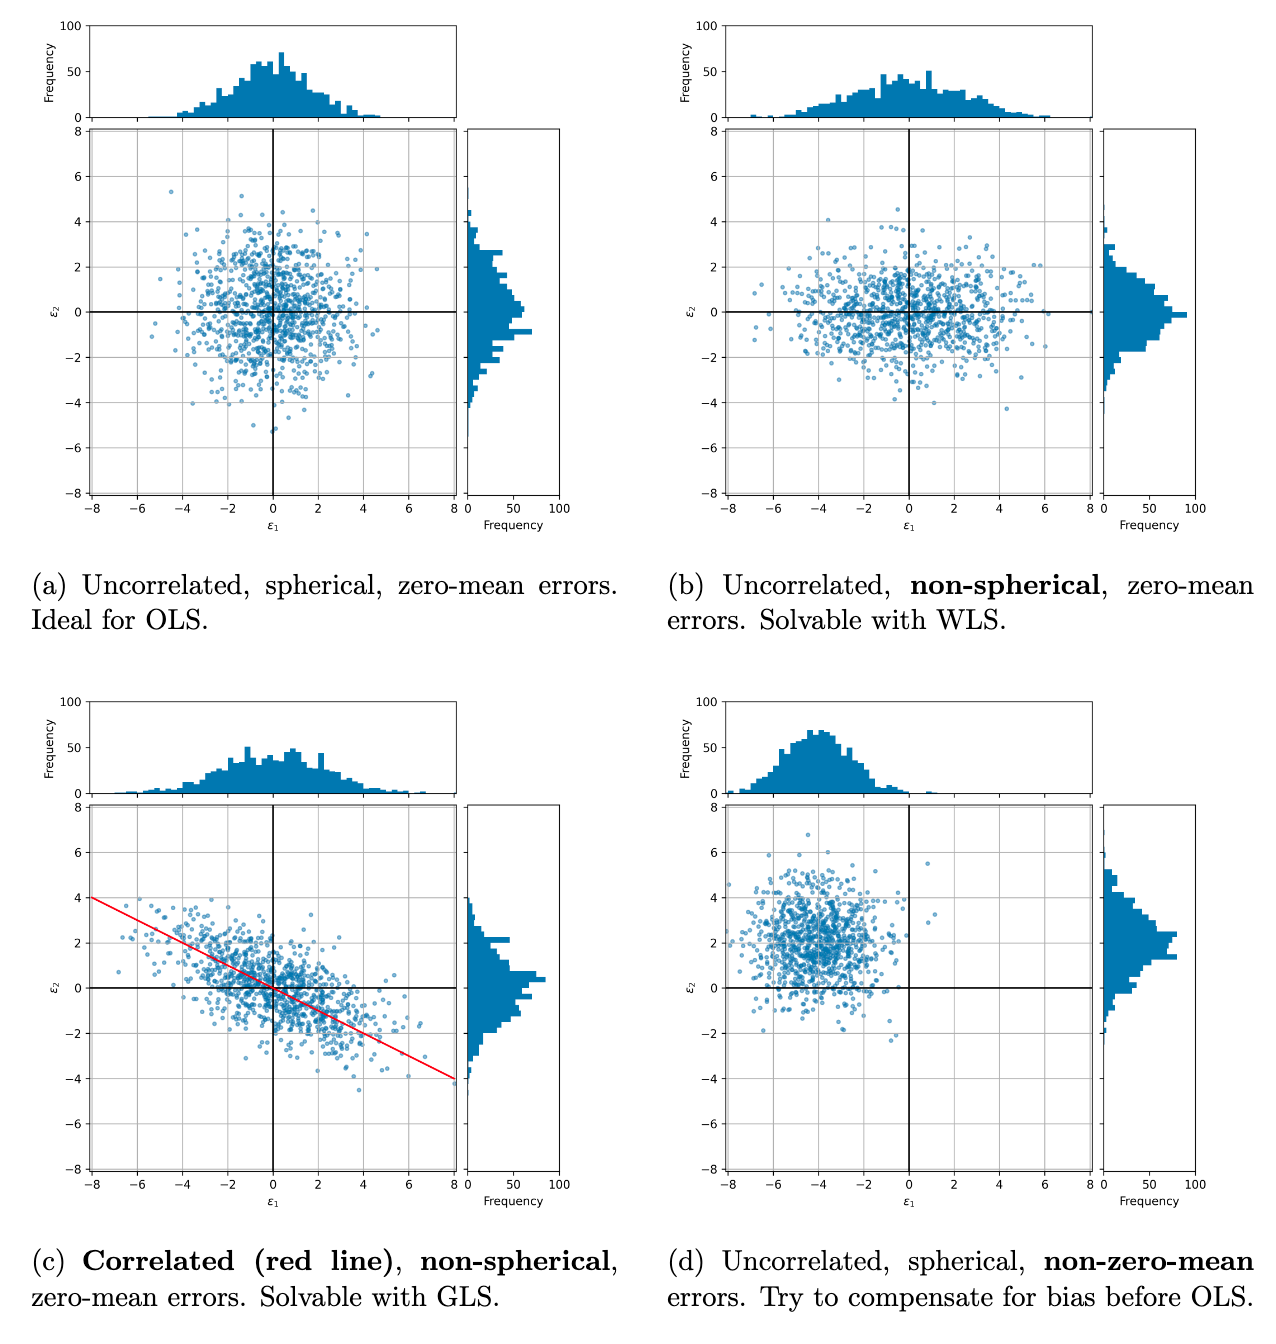

In [ ]:
# @title
from IPython.display import Image, display

display(Image(f"{notebooks_dir}/images/Correlations.png", width=800))

### 2.1 [4 Points]
By following very similar steps as in Lecture 4, show that the solution to the WLS problem is:
$$
\delta \mathbf{y} = (\mathbf{G}^\top \mathbf{W} \mathbf{G})^{-1} \mathbf{G}^\top \mathbf{W} \delta \rho
$$
This is called the **weighted least-squares solution**.

***ANSWER***

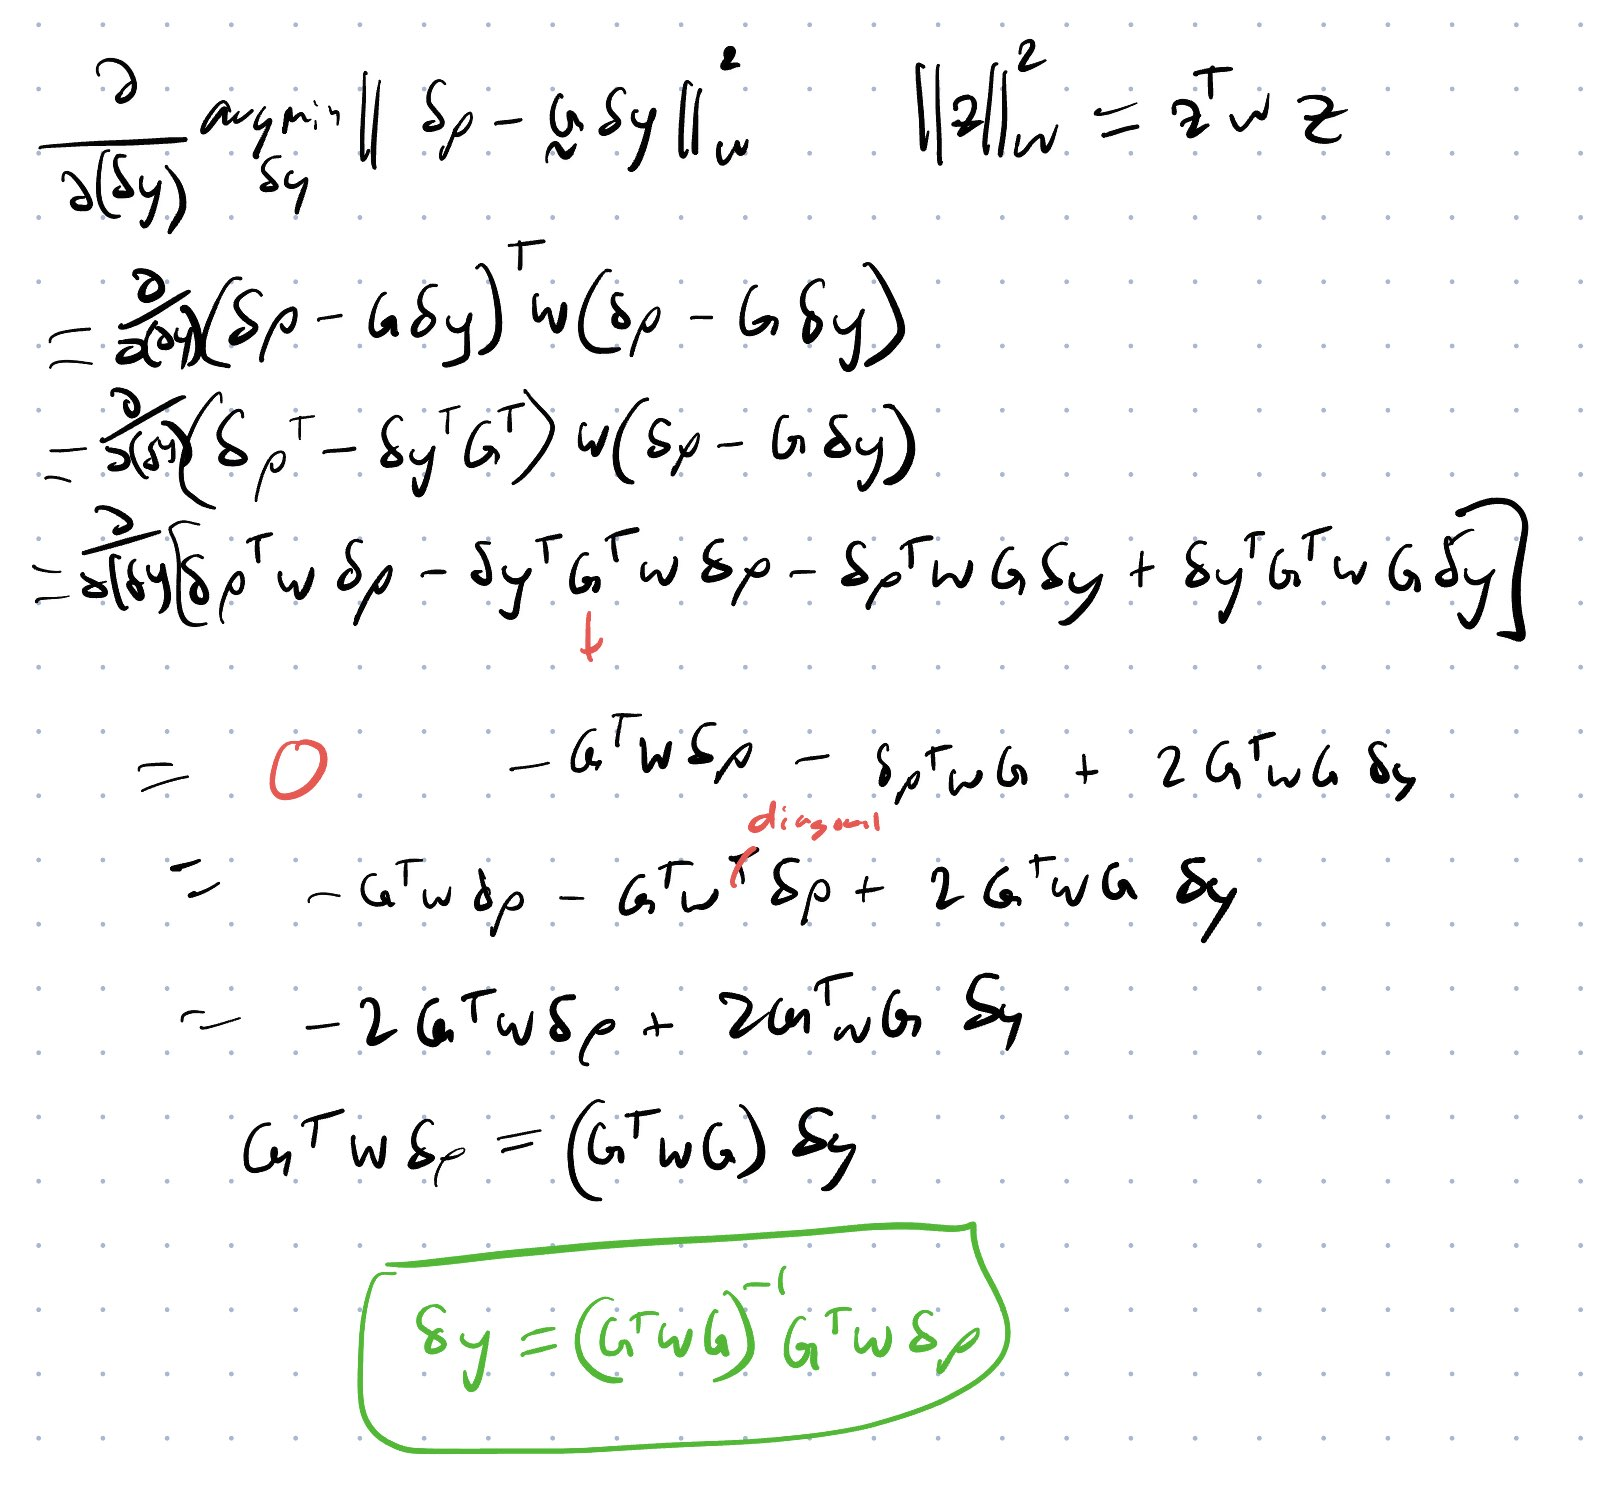

In [ ]:
display(Image(f"{notebooks_dir}/images/Derivation.jpg", width=800))

The derivation was carried out with the weighting matrix in the middle of the terms. Note that in the sixth line, when taking the transpose of the second term, $W^T$ is allowed to be reduced to $W$ because it is a diagonal matrix.

### 2.2 [2 Points]
Mathematically, why is it important for the diagonal weights of $\mathbf{W}$ to be **positive** for our defined problem statement and derivation?

*Hint:*

If you are stuck, head to Wolfram Alpha[4] and compare the output plots for each:

- Both positive weights: ` {x, y} * {{1/2, 0}, {0, 1}} * {x, y} `
- One negative weight: ` {x, y} * {{1/2, 0}, {0, -1}} * {x, y} `
- Different negative weight: ` {x, y} * {{-1/2, 0}, {0, 1}} * {x, y} `
- Both negative weights: ` {x, y} * {{-1/2, 0}, {0, -1}} * {x, y} `

[4]: Available at this link: [https://www.wolframalpha.com/](https://www.wolframalpha.com/)

***ANSWER***

### With regards to the definition:

For the least-squares problem to be well-posed and for the Newton Raphson method to converge to a minimum, $W$ must be strictly convex. This convexity is guaranteed if and only if $W$ is positive definite, meaning that it has a minimum point (and we want to minimize errors).

Similar to how multiplying a positive number by a negative number is negative, when you multiply this $W$ matrix in the pseudo-inverse equation, if it is not positive definite, then it will not converge.

### Plots

The Wolfram alpha plot for positive weights is concave up in both the X and Y directions with a global minumum. For one negative weight, the plot creates a saddle point (no global max or min). For both negative weights, the plot is completely concave down, with a global maximum.

Intuitively, because the Newton-Raphson method needs to find the minimum to settle on a final value for position, the gradient descent method of "subtracting" the error will put the current estiamate closer to the final minimum-error value.

However, for negative weights on any diagonal entry, traveling down the gradient will not allow it to converge because it is concave down. This is equivalent to instead **adding** error, which causes the result to diverge.

e.g. If you are trying to converge at (1,1), and your current position is at (2,2), rather than subtracting your error of (1,1), it will add to give you a new estimate of (3,3).

### 2.3 [2 Points]
Why would some pseudorange measurements have better quality than others? In other words, why is assumption 2 (Errors have equal variance/spherical errors) violated in real measurements? Provide at least two concrete examples.

*Hint:* There are *many* possible answers. This problem set and lectures 1, 5, and 6 may provide some insights, but feel free to think outside the box!

***ANSWER***

### Atmosphere and physical obstructions
Satellites that are at low elevations travel through more of the atmosphere, and thus receive more attenuation. They are also more likely to go through/around trees, mountains, and buildings, which further attenuates the signal. Therefore, error in the direction of that satellite will have more variance than satellites that are overhead.

### Satellites in View (SIV)
Having more satellites in view increases the likelihood of having 4 really strong satellite signals. On the other hand, if there are fewer satellites in view, and if one or more of them are not strong signals, then the pseudorange measurements are more susceptible to errors.

### Outdated ephimeris data
Having outdated ephimeris data causes the receiver to have incorrect satellite locations.

### 2.4 [2 Points]
Provide at least one concrete example where the errors are **correlated** (i.e., violating assumption 1), and at least one concrete example where the errors do not have **zero means** (i.e., violating assumption 3). *Note that weighted least-squares cannot handle these errors on its own.

*Note:* You may consider the corrections we applied in problem 1 and other insights from the problem 2 and 3 descriptions. However, there are *many* possible answers. Lectures 1, 5, and 6 may provide some insights, but feel free to think outside the box!
            
*Hint:* If you are stuck, think back to problem 2 on homework 1.
From the skyplots, there are often satellites with similar elevation and azimuth in a multi-constellation setting.
Are there errors that similarly affect satellites in nearby elevation and azimuth?

***ANSWER***

### Correlated Errors
Having more noise—like thermal noise, for example—will cause the noise floor of the signal to increase. Because the GPS signals are already very faint, having more noise on top of it will increase the likelihood that the auto-correlation will not produce a valid Gold code for a satellite. Because this is noise, it will typically have zero-mean error. There could also be noise on the end of the receiver, which would affect its measurements for all satellites.

### Non-zero-mean Error
If the ephimeris is outdated, then the positions of all satellites will be incorrect. This causes there to be a constant non-zero-mean error for each satellite.